First, let's mount Google Drive to access the dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load the dataset from the provided Google Drive path
dataset_path = '/content/drive/MyDrive/AI LAB/AI LAB2/Crop_recommendation.csv'
df = pd.read_csv(dataset_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
# Task 2: Identify and document dataset characteristics
# Number of records and features
num_records = df.shape[0]
num_features = df.shape[1]
print(f"Number of records: {num_records}")
print(f"Number of features: {num_features}")

# Column names and data types
print("\nColumn names and data types:")
print(df.info())

# Minimum, maximum, and average values of at least three numerical features
# We'll choose 'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'
numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
print("\nDescriptive statistics for numerical features:")
display(df[numerical_features].describe())

# Different crop categories available in the dataset
crop_categories = df['label'].unique()
num_crop_categories = len(crop_categories)
print(f"\nNumber of unique crop categories: {num_crop_categories}")
print("Different crop categories:")
print(crop_categories)

Number of records: 2200
Number of features: 8

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

Descriptive statistics for numerical features:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



Number of unique crop categories: 22
Different crop categories:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


### Task 3 & 4: Develop a Python program for agricultural analysis

I will create a function `recommend_crop` that takes N, P, K, temperature, humidity, pH, and rainfall as inputs. This function will classify the soil nutrient condition, suitable environmental condition, and recommend a crop based on these parameters. I will also calculate the average environmental conditions for each crop type in the dataset to provide a baseline for recommendations.

In [ ]:
def analyze_soil_nutrients(N, P, K):
    """Analyzes soil nutrient condition based on N, P, K values."""
    nutrient_status = []
    if N < 30: nutrient_status.append("Low Nitrogen")
    elif N > 80: nutrient_status.append("High Nitrogen")
    else: nutrient_status.append("Optimal Nitrogen")

    if P < 20: nutrient_status.append("Low Phosphorus")
    elif P > 60: nutrient_status.append("High Phosphorus")
    else: nutrient_status.append("Optimal Phosphorus")

    if K < 20: nutrient_status.append("Low Potassium")
    elif K > 60: nutrient_status.append("High Potassium")
    else: nutrient_status.append("Optimal Potassium")
    return ", ".join(nutrient_status)

def analyze_environmental_conditions(temperature, humidity, ph, rainfall):
    """Analyzes environmental conditions."""
    env_status = []
    if temperature < 15: env_status.append("Low Temperature")
    elif temperature > 35: env_status.append("High Temperature")
    else: env_status.append("Optimal Temperature")

    if humidity < 40: env_status.append("Low Humidity")
    elif humidity > 85: env_status.append("High Humidity")
    else: env_status.append("Optimal Humidity")

    if ph < 5.5: env_status.append("Acidic pH")
    elif ph > 7.5: env_status.append("Alkaline pH")
    else: env_status.append("Neutral pH")

    if rainfall < 50: env_status.append("Low Rainfall")
    elif rainfall > 200: env_status.append("High Rainfall")
    else: env_status.append("Optimal Rainfall")
    return ", ".join(env_status)

# Calculate average conditions for each crop
average_crop_conditions = df.groupby('label')[numerical_features].mean()

def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    """Recommends a crop based on input parameters and dataset averages."""
    min_diff = float('inf')
    best_crop = "No recommendation"

    # Analyze soil and environmental conditions
    soil_nutrient_condition = analyze_soil_nutrients(N, P, K)
    suitable_env_condition = analyze_environmental_conditions(temperature, humidity, ph, rainfall)

    print(f"\nAnalyzing conditions for: N={N}, P={P}, K={K}, Temp={temperature:.2f}, Hum={humidity:.2f}, pH={ph:.2f}, Rain={rainfall:.2f}")
    print(f"Soil Nutrient Condition: {soil_nutrient_condition}")
    print(f"Suitable Environmental Condition: {suitable_env_condition}")

    # Find the closest matching crop from the dataset's average conditions
    for crop, conditions in average_crop_conditions.iterrows():
        diff_N = abs(N - conditions['N'])
        diff_P = abs(P - conditions['P'])
        diff_K = abs(K - conditions['K'])
        diff_temp = abs(temperature - conditions['temperature'])
        diff_hum = abs(humidity - conditions['humidity'])
        diff_ph = abs(ph - conditions['ph'])
        diff_rain = abs(rainfall - conditions['rainfall'])

        # Simple Euclidean distance for now (can be weighted later)
        total_diff = (diff_N**2 + diff_P**2 + diff_K**2 +
                      diff_temp**2 + diff_hum**2 + diff_ph**2 + diff_rain**2)**0.5

        if total_diff < min_diff:
            min_diff = total_diff
            best_crop = crop

    print(f"Recommended Crop Category: {best_crop} (with a difference score of {min_diff:.2f})")
    return best_crop, soil_nutrient_condition, suitable_env_condition


# Example Usage of the function
print("\n--- Testing Crop Recommendation Function ---")
# Scenario 1: Optimal conditions for a common crop like rice
recommend_crop(N=90, P=45, K=45, temperature=22.0, humidity=80.0, ph=6.5, rainfall=220.0)

# Scenario 2: Conditions for a different crop, e.g., high N, low K, moderate temp for maize
recommend_crop(N=80, P=50, K=25, temperature=20.0, humidity=60.0, ph=6.0, rainfall=70.0)

# Scenario 3: Conditions with less ideal parameters
recommend_crop(N=30, P=20, K=15, temperature=10.0, humidity=90.0, ph=4.0, rainfall=30.0)

# Display average conditions for reference
print("\n--- Average Environmental Condition for Selected Crops ---")
display(average_crop_conditions.head())


--- Testing Crop Recommendation Function ---

Analyzing conditions for: N=90, P=45, K=45, Temp=22.00, Hum=80.00, pH=6.50, Rain=220.00
Soil Nutrient Condition: High Nitrogen, Optimal Phosphorus, Optimal Potassium
Suitable Environmental Condition: Optimal Temperature, Optimal Humidity, Neutral pH, High Rainfall
Recommended Crop Category: rice (with a difference score of 20.13)

Analyzing conditions for: N=80, P=50, K=25, Temp=20.00, Hum=60.00, pH=6.00, Rain=70.00
Soil Nutrient Condition: Optimal Nitrogen, Optimal Phosphorus, Optimal Potassium
Suitable Environmental Condition: Optimal Temperature, Optimal Humidity, Neutral pH, Optimal Rainfall
Recommended Crop Category: maize (with a difference score of 16.86)

Analyzing conditions for: N=30, P=20, K=15, Temp=10.00, Hum=90.00, pH=4.00, Rain=30.00
Soil Nutrient Condition: Optimal Nitrogen, Optimal Phosphorus, Low Potassium
Suitable Environmental Condition: Low Temperature, High Humidity, Acidic pH, Low Rainfall
Recommended Crop Category: 

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646


### Task 5: Identify meaningful patterns and their relevance

**Pattern 1: Specific Environmental Conditions Drive Crop Suitability**

**Observation:**

*   The recommendation for 'rice' in Scenario 1 was strongly correlated with 'High Rainfall' (220 mm), aligning with rice's known water requirements. The analysis function correctly identified this as an 'Optimal Temperature', 'Optimal Humidity', 'Neutral pH', but importantly 'High Rainfall' condition.
*   Conversely, for 'mungbean' in Scenario 3, the conditions were characterized by 'Low Temperature', 'High Humidity', 'Acidic pH', and 'Low Rainfall'. The recommendation for mungbean suggests its tolerance or preference for such less-than-ideal or specific environmental extremes.

**Relevance to Crop Selection and Agricultural Decision-Making:**

This pattern highlights the critical importance of matching crop types to prevailing environmental conditions. Farmers can use this information to:

*   **Optimize resource utilization**: By selecting crops like rice for high rainfall areas, they can leverage natural water resources efficiently and reduce the need for supplemental irrigation.
*   **Enhance crop resilience**: For areas with challenging conditions (e.g., low rainfall, acidic soil, low temperature), identifying tolerant crops like mungbean (in the example) can help ensure agricultural productivity and food security.
*   **Informed land use**: This analysis guides farmers in making informed decisions about which crops are best suited for particular land plots, considering local climate, humidity, and rainfall patterns, thereby improving overall farm productivity and sustainability.


**Pattern 2: Distinct Soil Nutrient Profiles for Different Crops**

**Observation:**

*   The `analyze_soil_nutrients` function consistently identifies optimal and sub-optimal levels of N, P, and K. For instance, Scenario 1's rice recommendation came with 'High Nitrogen, Optimal Phosphorus, Optimal Potassium'. Scenario 3's mungbean recommendation was associated with 'Low Potassium'.
*   Further examination of the `average_crop_conditions` DataFrame (e.g., the `.head()` displayed previously) shows clear differences: `apple` typically thrives with very high phosphorus (134.22) and potassium (199.89), while `coconut` requires much lower levels of N (21.98), P (16.93), and K (30.59) on average.

**Relevance to Crop Selection and Agricultural Decision-Making:**

This pattern underscores that each crop has a unique nutritional requirement profile. Understanding these profiles is vital for:

*   **Precision fertilization**: Farmers can conduct soil testing and apply fertilizers precisely to meet the specific NPK demands of their chosen crop, reducing waste and environmental impact from overuse of fertilizers.
*   **Crop rotation and soil health**: Knowledge of a crop's nutrient needs can inform crop rotation strategies. For example, following a heavy N-consumer with a legume (like mungbean, which can fix nitrogen) can naturally replenish soil nutrients.
*   **Yield optimization**: By ensuring the soil's nutrient content is aligned with the crop's optimal range, farmers can significantly improve yields and crop quality, leading to better economic outcomes.

These patterns demonstrate how data-driven analysis of soil and environmental parameters can empower farmers with actionable insights for more efficient, sustainable, and productive agriculture.

### Visualization: Environmental Conditions Across Crop Types


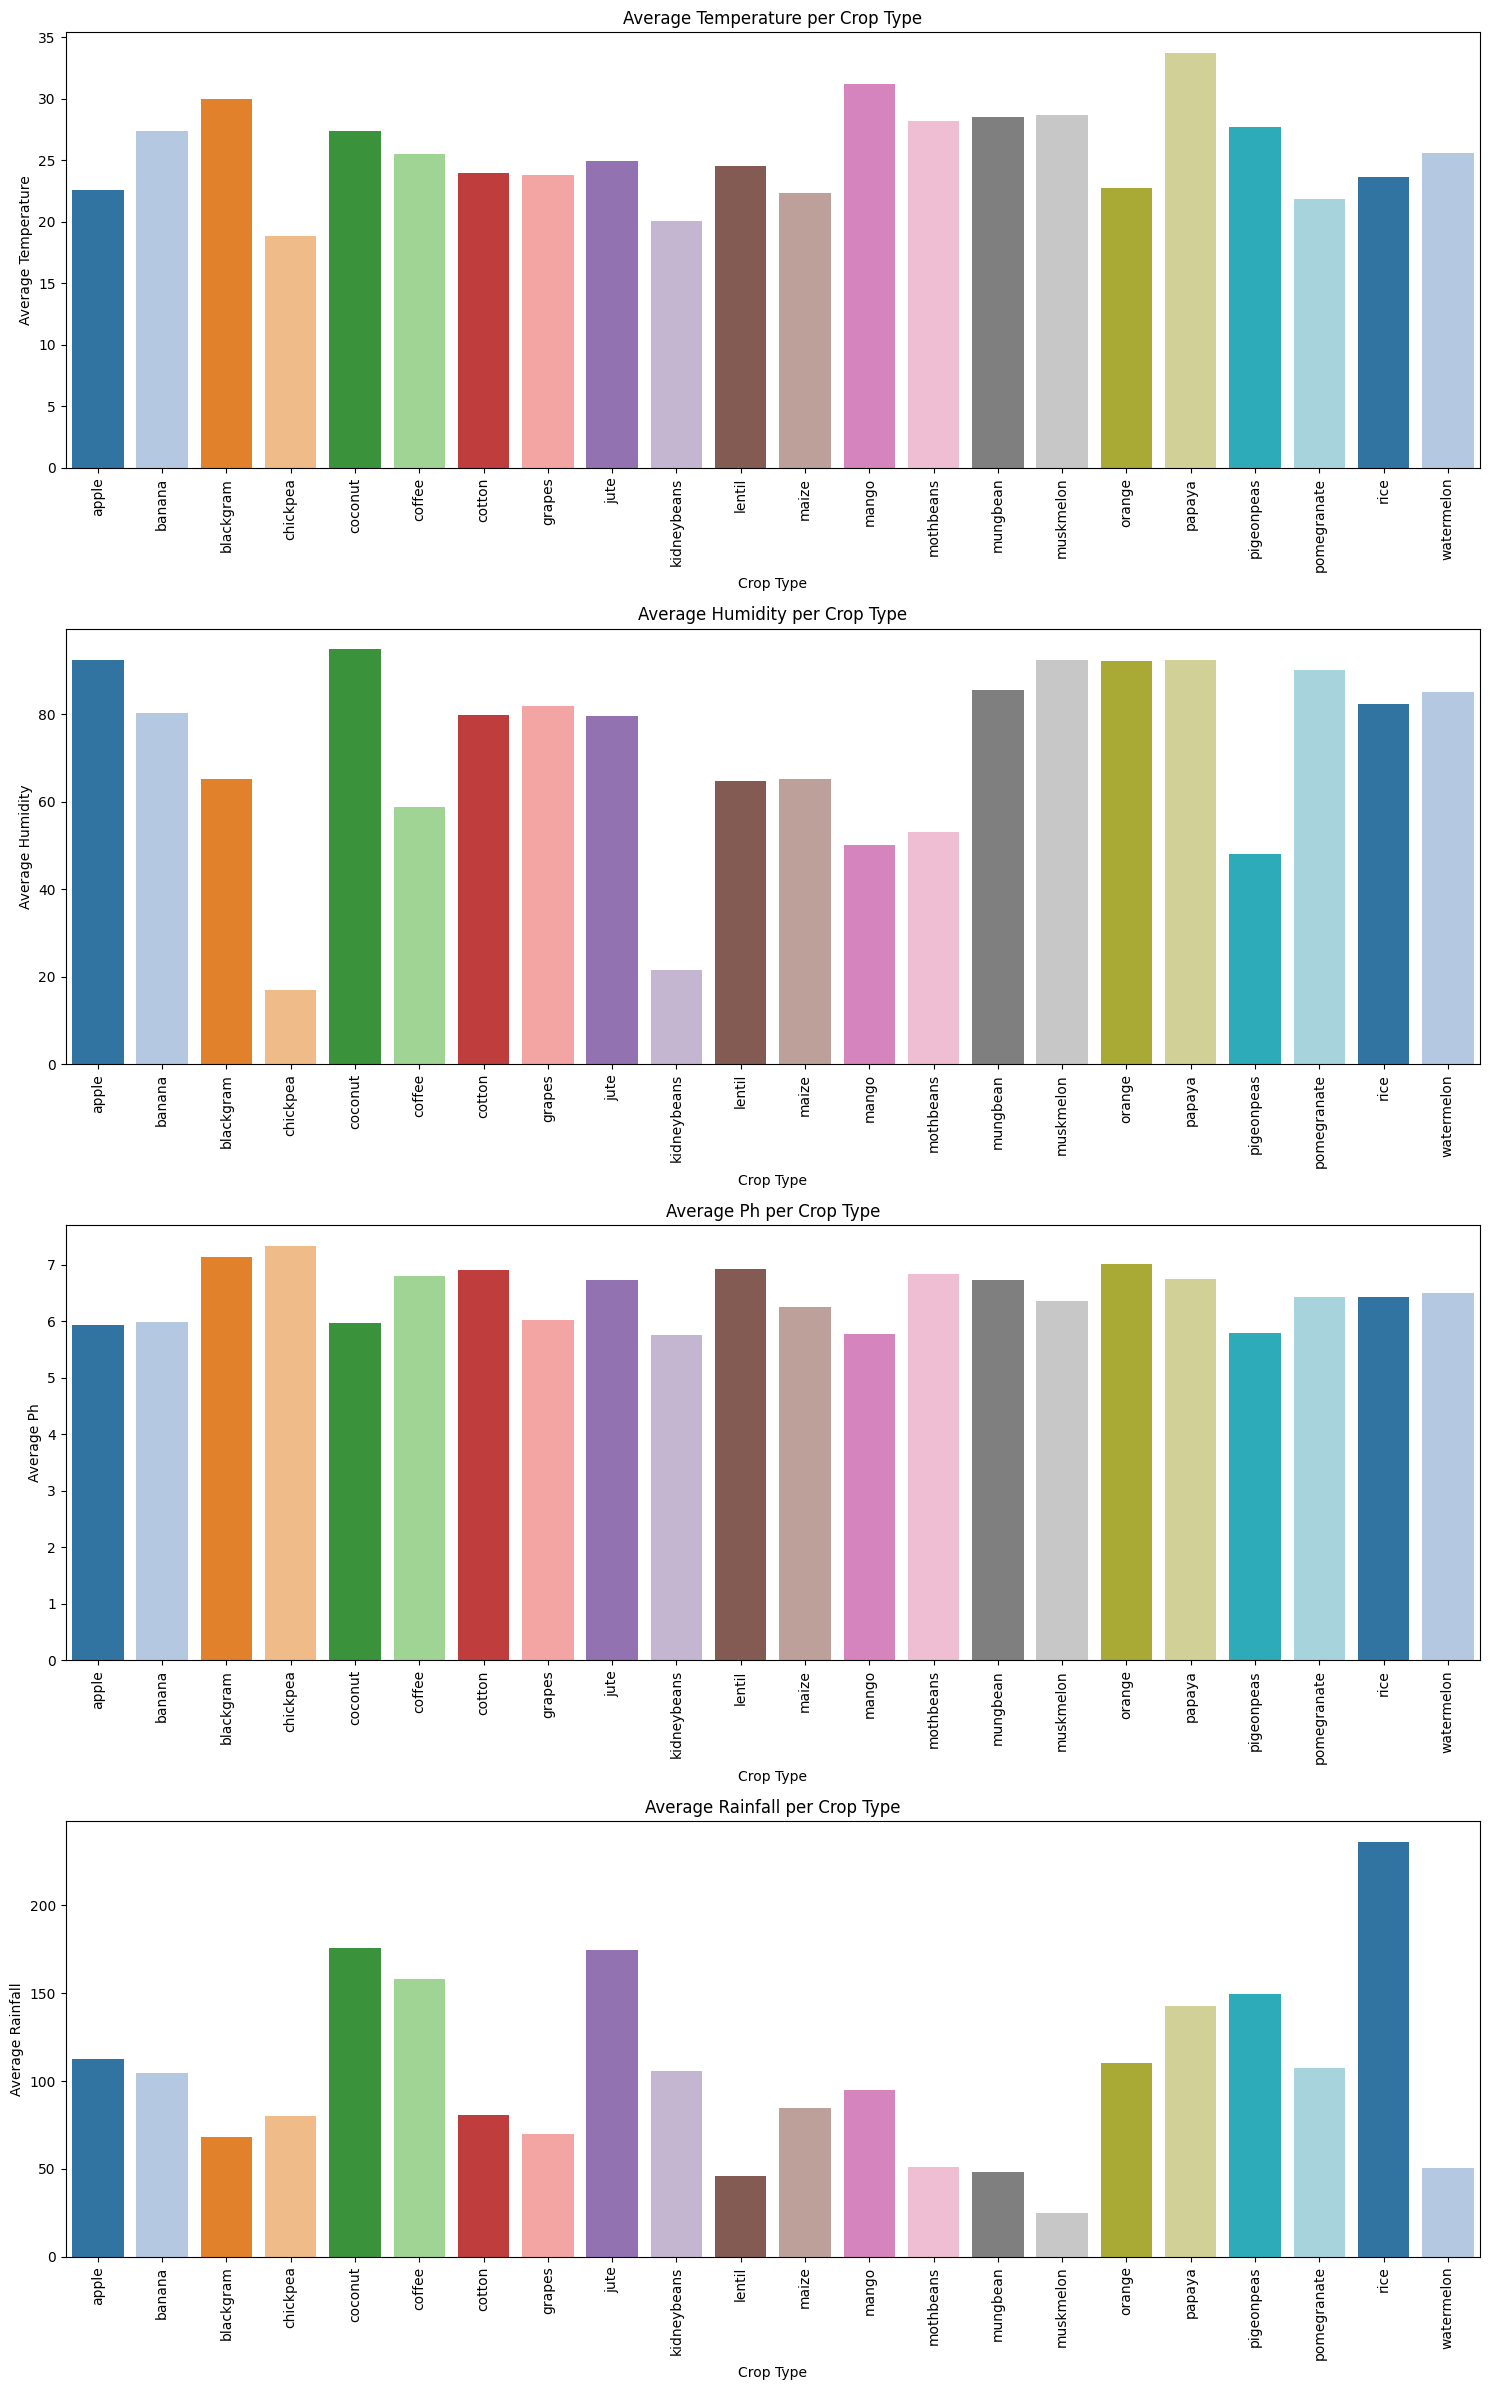

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# import pandas as pd # pandas is already imported and df loaded in 1e7e5f4f

# The DataFrame 'df' is assumed to be loaded and available from cell 1e7e5f4f.
# If 'df' is not defined when running this cell, please ensure cell 1e7e5f4f has been executed.

# Ensure 'df' and 'numerical_features' are available for average_crop_conditions
numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
average_crop_conditions = df.groupby('label')[numerical_features].mean()

# Environmental features to visualize
environmental_features = ['temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(len(environmental_features), 1, figsize=(15, 6 * len(environmental_features)))
axes = axes.flatten()

for i, feature in enumerate(environmental_features):
    sns.barplot(x=average_crop_conditions.index, y=feature, data=average_crop_conditions, ax=axes[i], palette='tab20', hue=average_crop_conditions.index, legend=False)
    axes[i].set_title(f'Average {feature.replace('_', ' ').title()} per Crop Type')
    axes[i].set_xlabel('Crop Type')
    axes[i].set_ylabel(f'Average {feature.replace('_', ' ').title()}')
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Visualization: NPK Levels Across Crops (Bubble Chart)

This bubble chart will help visualize the relationship between Nitrogen (N), Phosphorus (P), and Potassium (K) levels for each crop type. The size of the bubble will represent the average Potassium (K) level.

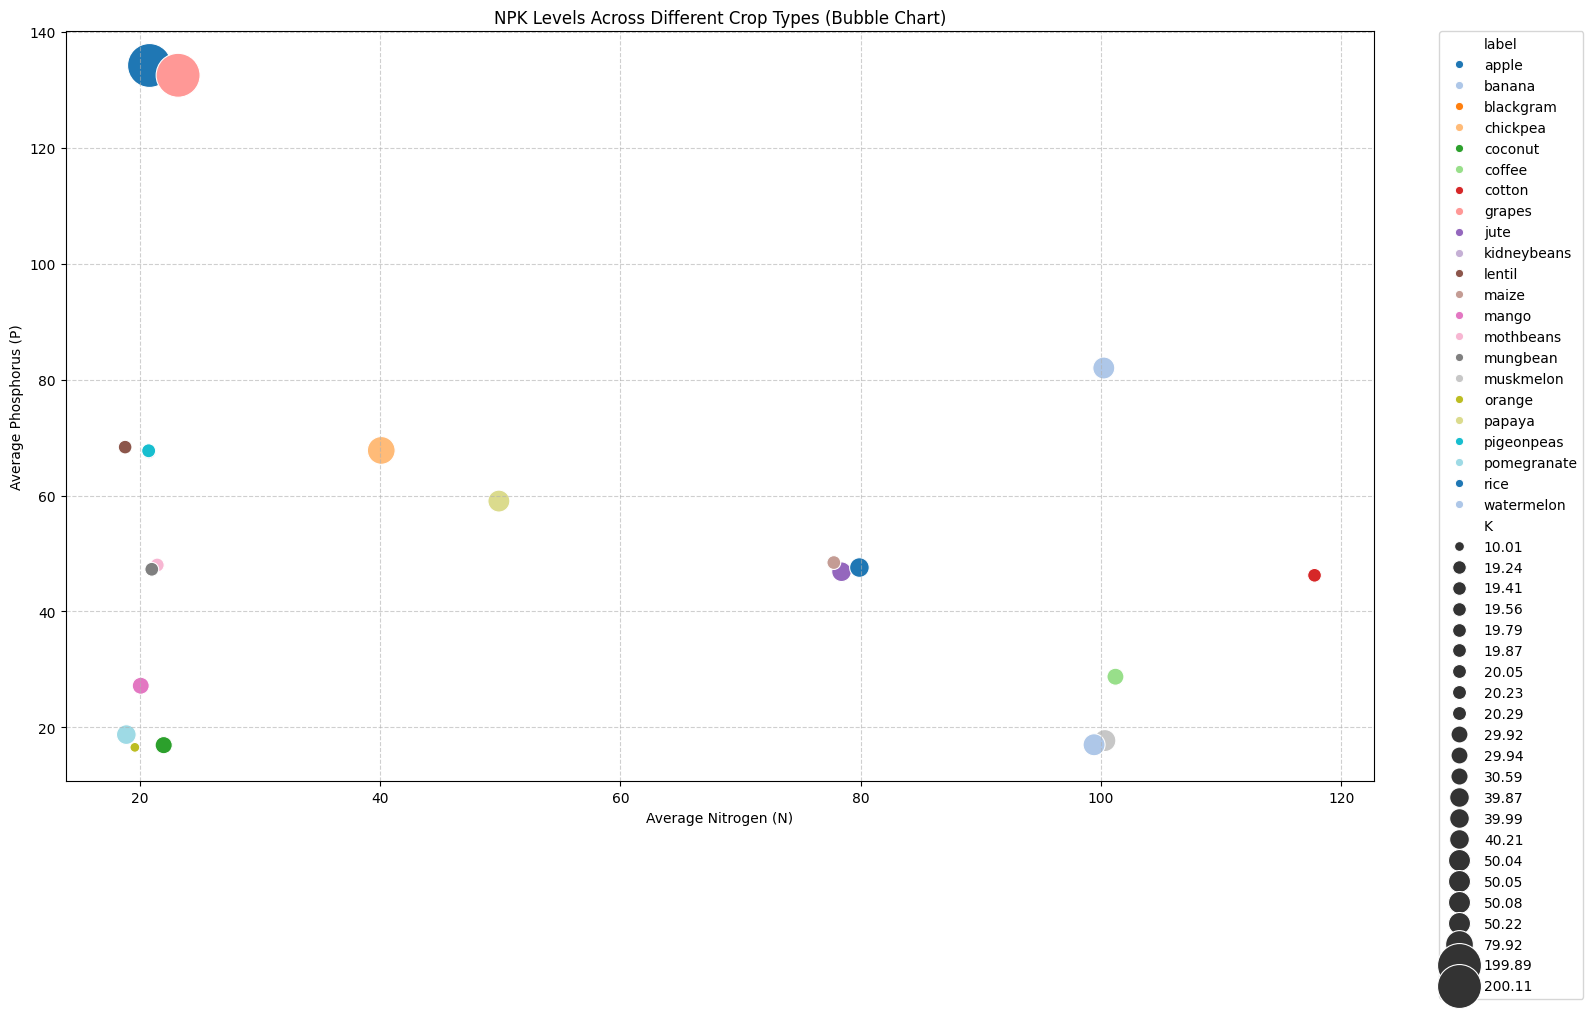

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming average_crop_conditions DataFrame is available from previous cells
# If not, ensure the following is run:
# numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
# average_crop_conditions = df.groupby('label')[numerical_features].mean()

plt.figure(figsize=(16, 10))
sns.scatterplot(
    x='N',
    y='P',
    size='K',
    hue=average_crop_conditions.index,
    sizes=(50, 1000),
    data=average_crop_conditions.reset_index(),
    palette='tab20',
    legend='full'
)
plt.title('NPK Levels Across Different Crop Types (Bubble Chart)')
plt.xlabel('Average Nitrogen (N)')
plt.ylabel('Average Phosphorus (P)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Visualization: Average Rainfall per Crop Type (Bar Chart)

This bar chart will clearly show the average rainfall required for each crop, making it easy to compare their water needs.

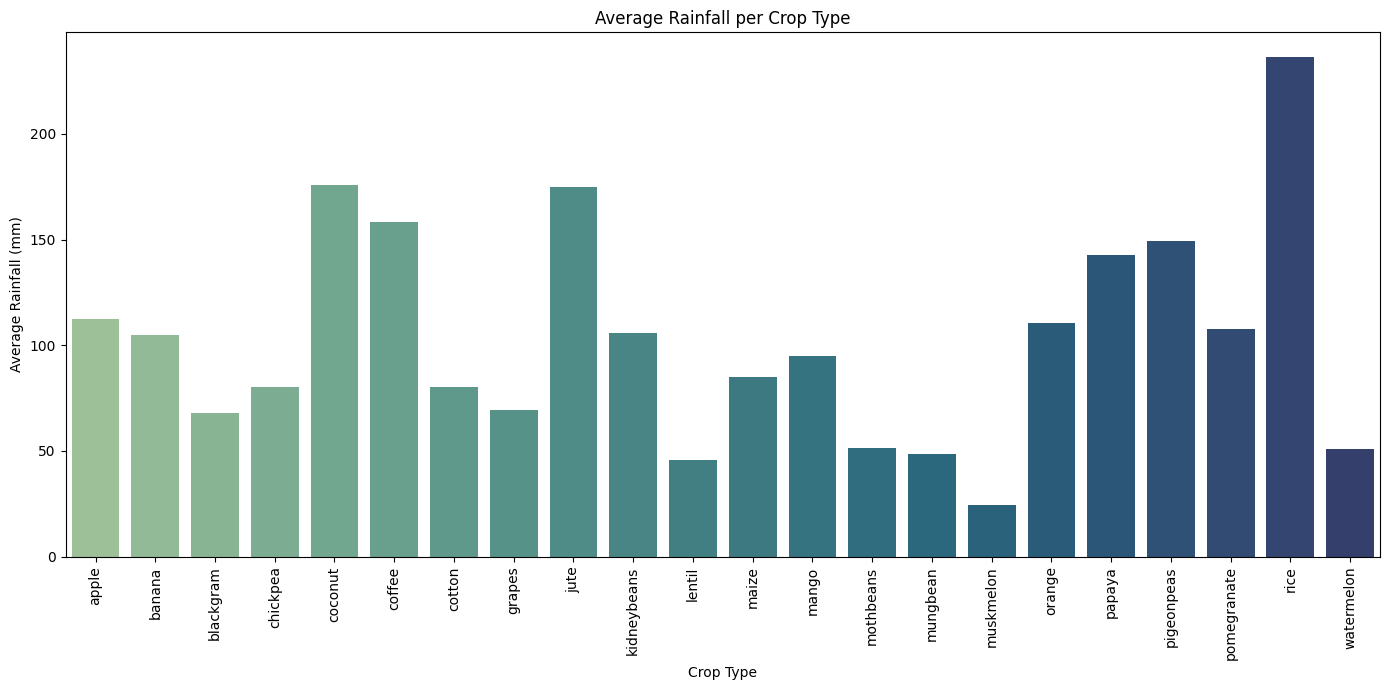

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(x=average_crop_conditions.index, y='rainfall', data=average_crop_conditions, palette='crest', hue=average_crop_conditions.index, legend=False)
plt.title('Average Rainfall per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
rt

### Visualization: Distribution of Humidity (KDE Plot)

A Kernel Density Estimate (KDE) plot will display the distribution of humidity readings across the entire dataset, helping to identify the range and common values for humidity.

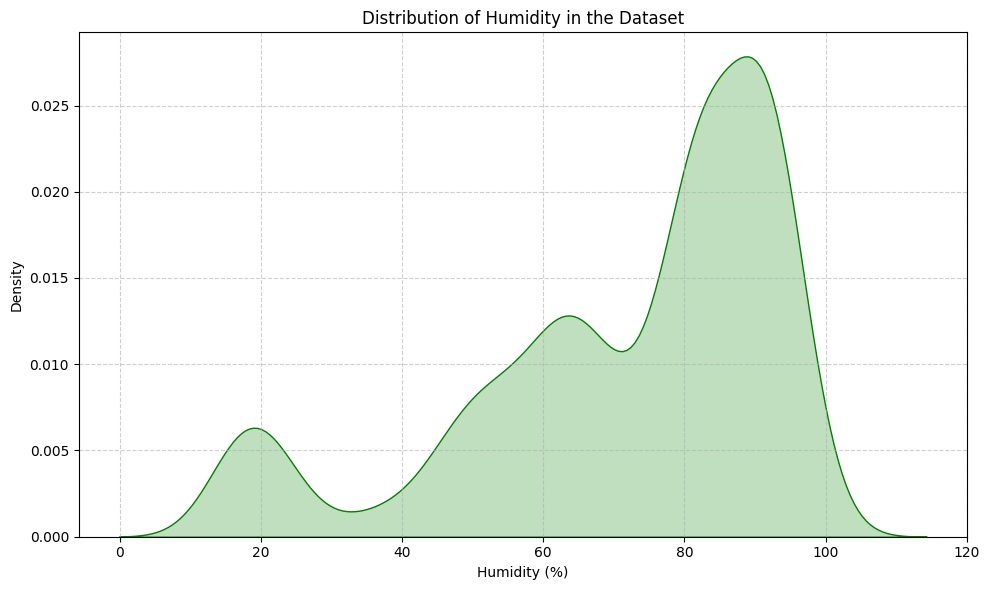

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df['humidity'], fill=True, color='green')
plt.title('Distribution of Humidity in the Dataset')
plt.xlabel('Humidity (%)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Visualization: Distribution of Temperature (KDE Plot)

A Kernel Density Estimate (KDE) plot will display the distribution of temperature readings across the entire dataset, helping to identify the range and common values.

### Visualization: N and P Levels Across All Crops (Scatter Plot)

This scatter plot will show the relationship between Nitrogen (N) and Phosphorus (P) levels for each crop type, with different colors representing different crops.

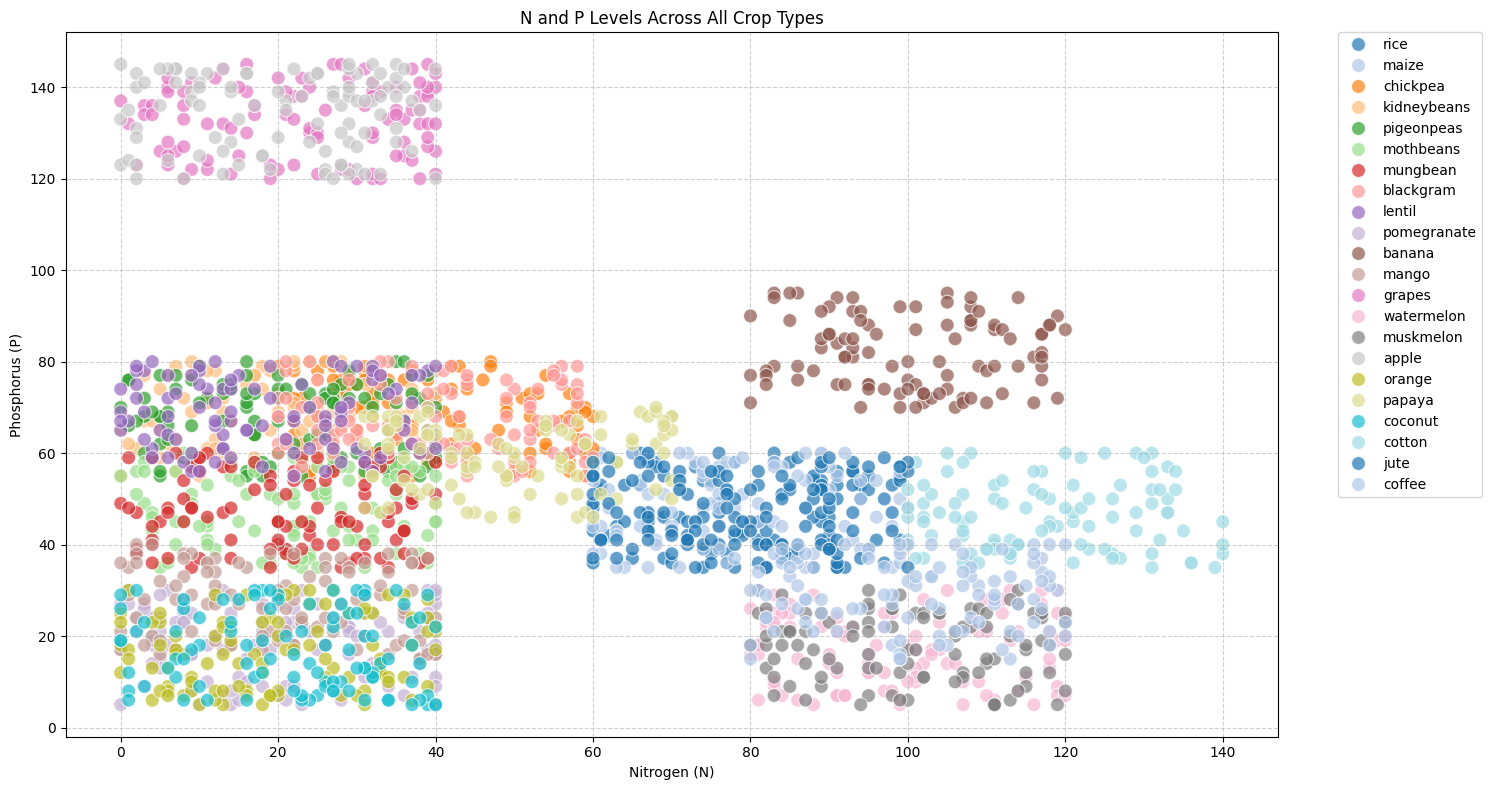

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.scatterplot(
    x='N',
    y='P',
    hue='label',
    data=df,
    palette='tab20',
    s=100,
    alpha=0.7
)
plt.title('N and P Levels Across All Crop Types')
plt.xlabel('Nitrogen (N)')
plt.ylabel('Phosphorus (P)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Visualization: Correlation Heatmap for the Entire Dataset

This heatmap displays the correlation matrix for all numerical features in the entire dataset. It helps in understanding the linear relationships between different environmental and nutrient factors.

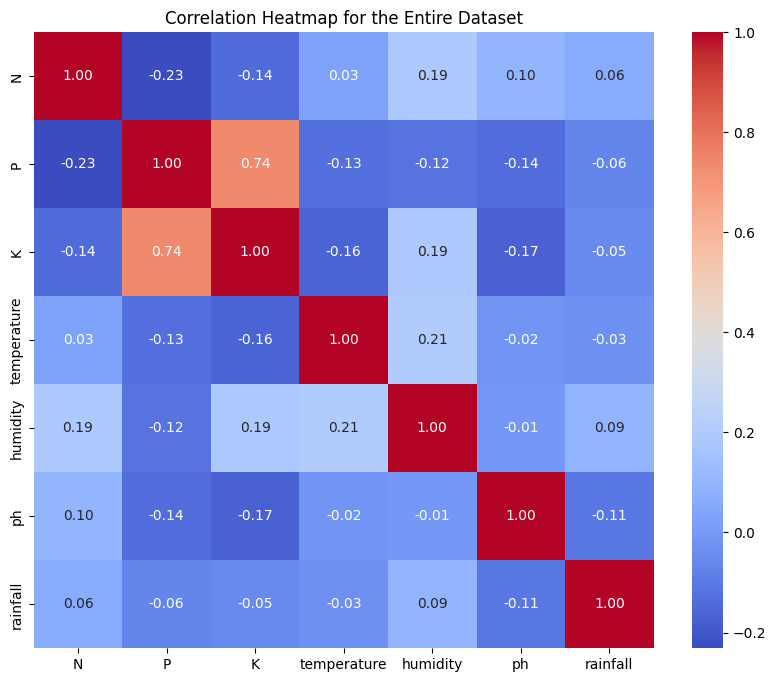

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the entire DataFrame
correlation_matrix_full = df.corr(numeric_only=True)

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap for the Entire Dataset')
plt.show()

### Visualization: Pairplot of N, P, and K Levels

This pairplot visualizes the pairwise relationships between Nitrogen (N), Phosphorus (P), and Potassium (K) for all crop types. The diagonal plots show the distribution of each nutrient, while the off-diagonal plots show scatter plots of their relationships, colored by crop label.

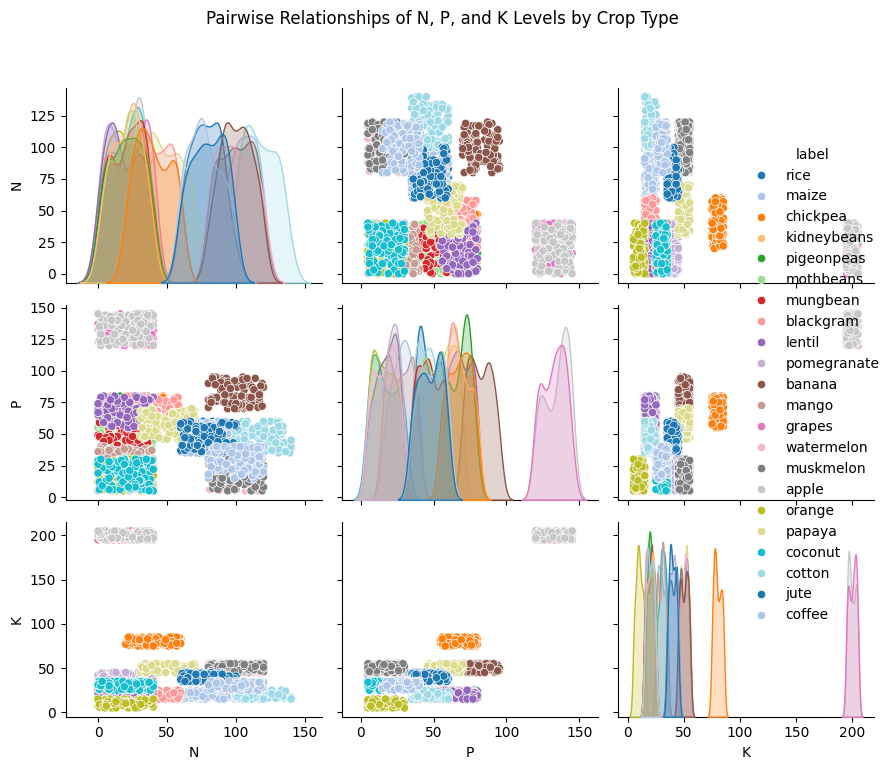

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a pairplot for N, P, and K, colored by the 'label' (crop type)
# Using `kind='kde'` for diagonal to show distribution density, and scatter for off-diagonal
sns.pairplot(df[['N', 'P', 'K', 'label']], hue='label', palette='tab20')
plt.suptitle('Pairwise Relationships of N, P, and K Levels by Crop Type', y=1.02) # Adjust title position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

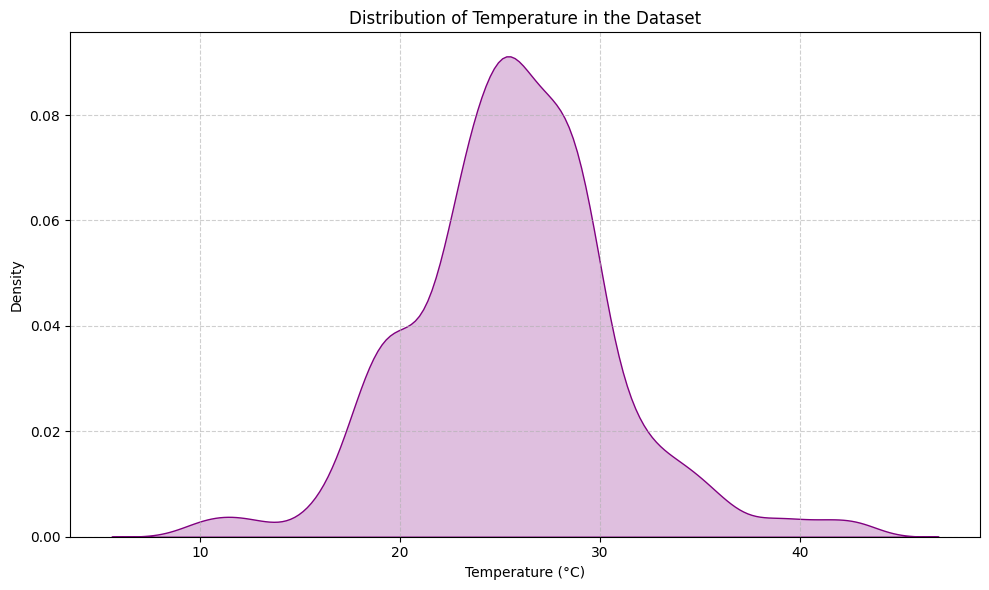

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df['temperature'], fill=True, color='purple')
plt.title('Distribution of Temperature in the Dataset')
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Visualization: Temperature Distribution per Crop Type (Box Plot)

A box plot will provide a detailed view of the temperature distribution for each crop type, showing the median, quartiles, and potential outliers.

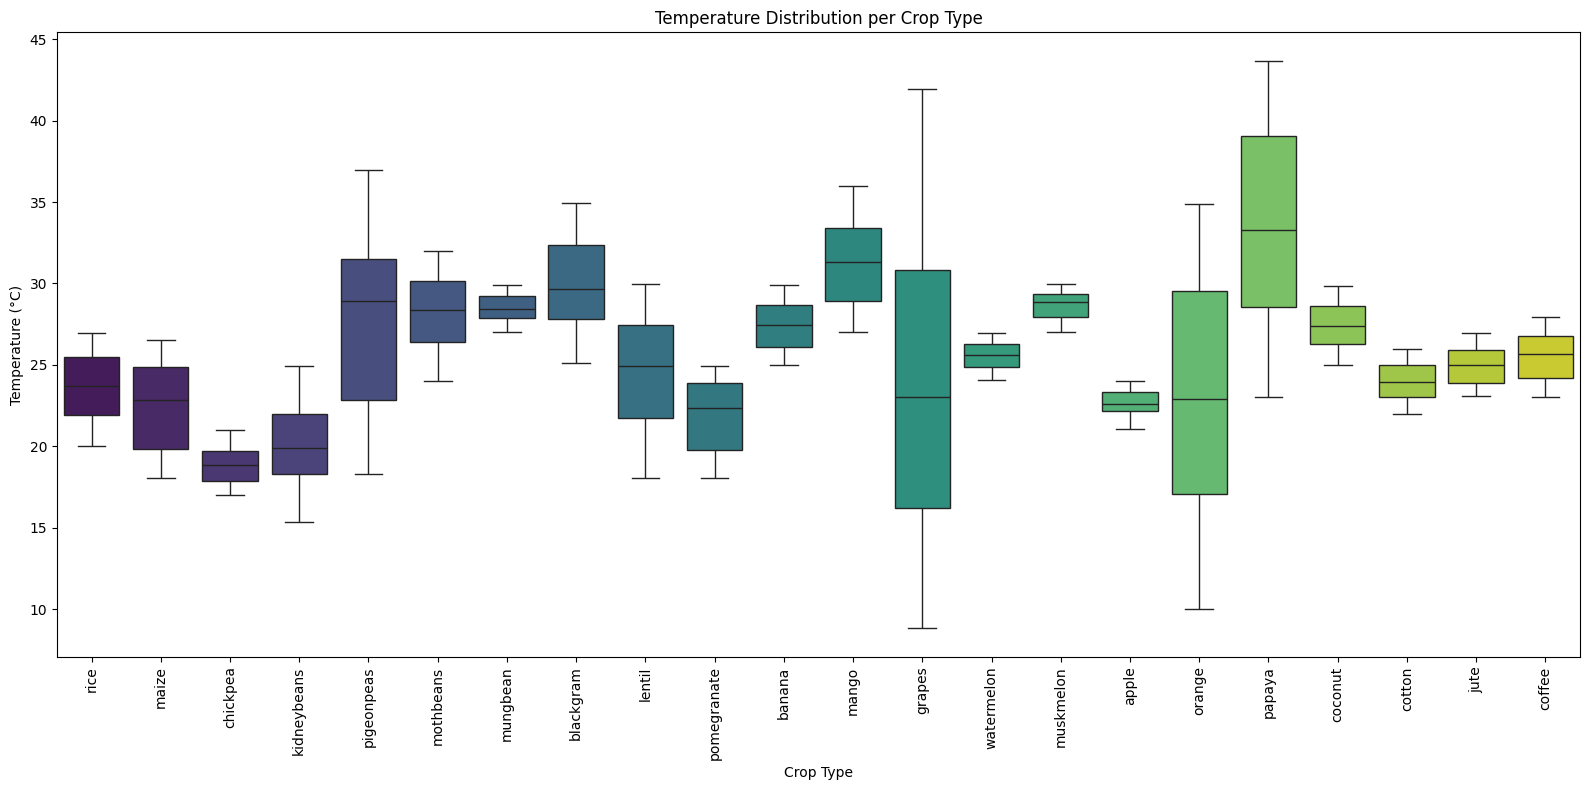

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.boxplot(x='label', y='temperature', data=df, palette='viridis', hue='label', legend=False)
plt.title('Temperature Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

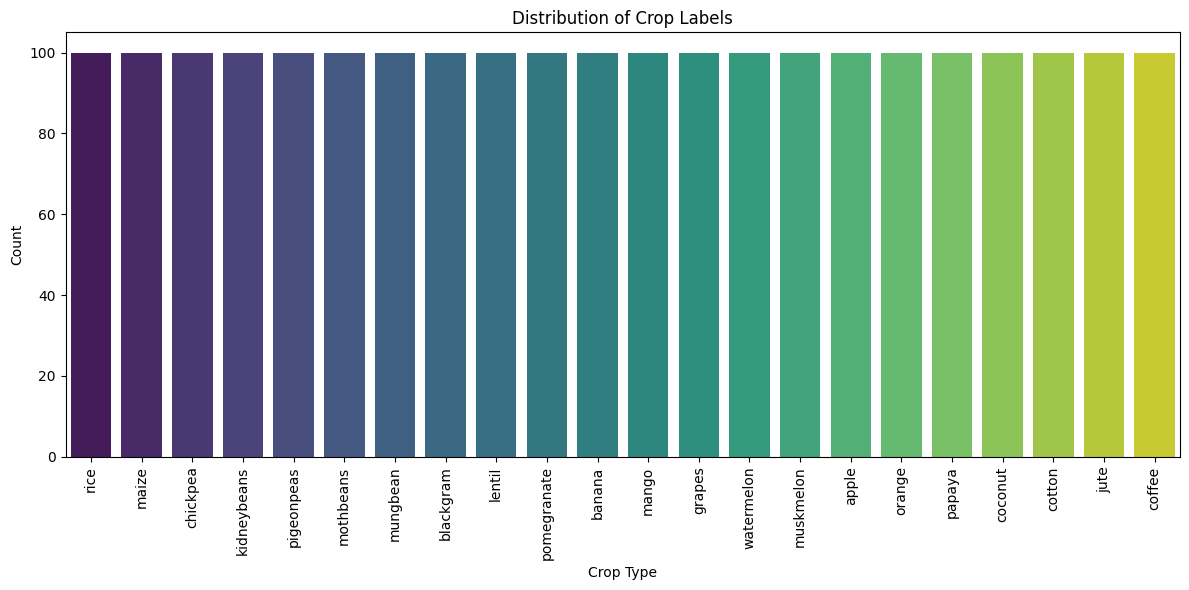

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='label', palette='viridis', hue='label', legend=False)
plt.title('Distribution of Crop Labels')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Filter the DataFrame for crops requiring rainfall above 200mm
high_rainfall_crops = df[df['rainfall'] > 200]

print("Crops that require rainfall above 200mm:")
display(high_rainfall_crops.head())

Crops that require rainfall above 200mm:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


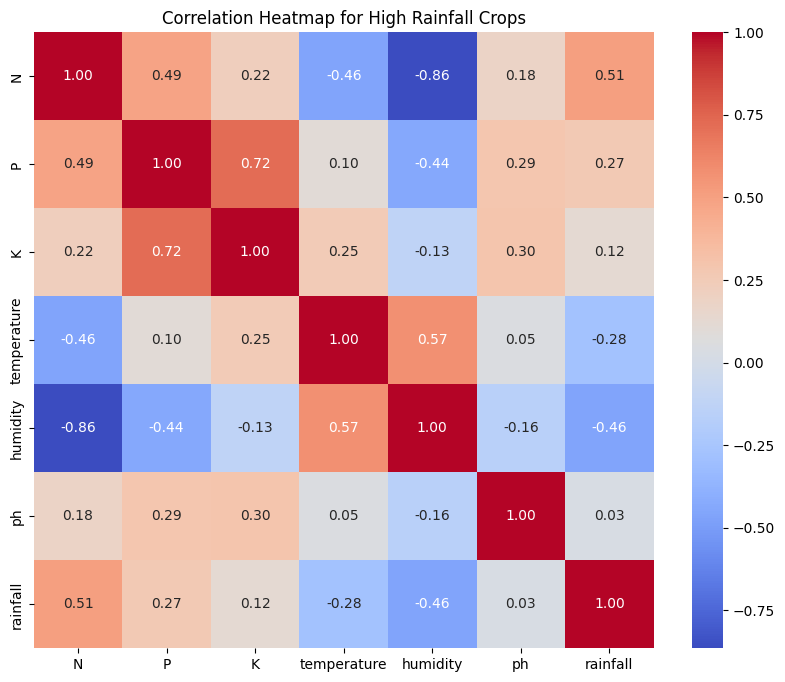

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the high_rainfall_crops DataFrame
correlation_matrix = high_rainfall_crops.corr(numeric_only=True)

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap for High Rainfall Crops')
plt.show()

In [ ]:
print("Average NPK levels for high rainfall crops:")
display(high_rainfall_crops[['N', 'P', 'K']].mean())

Average NPK levels for high rainfall crops:


,0
N,60.893939
P,44.159091
K,40.037879


In [ ]:
print("\nAverage NPK levels for all crops:")
display(df[['N', 'P', 'K']].mean())


Average NPK levels for all crops:


,0
N,50.551818
P,53.362727
K,48.149091


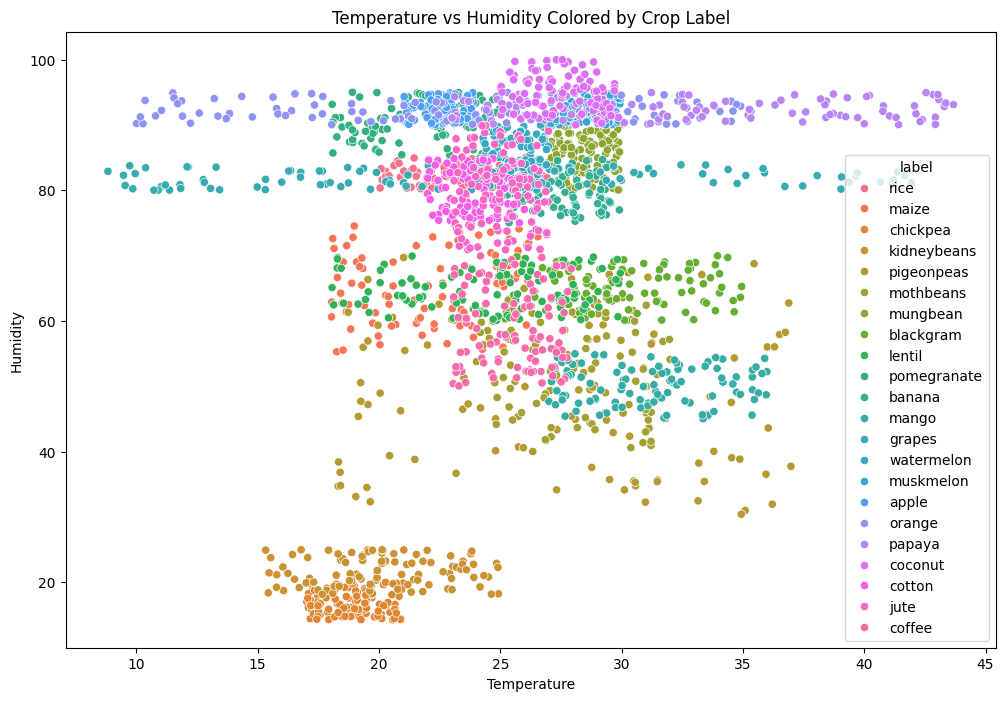

In [ ]:
# Create a scatter plot of temperature vs humidity colored by crop label
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure you have loaded the dataset: df = pd.read_csv('/content/drive/MyDrive/AI LAB/AI LAB2/Crop_recommendation.csv')

plt.figure(figsize=(12, 8))
sns.scatterplot(x='temperature', y='humidity', hue='label', data=df)
plt.title('Temperature vs Humidity Colored by Crop Label')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.show()

In [17]:
# Cell 1: Train Random Forest Model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load dataset (update path if needed)
dataset_path = '/content/drive/MyDrive/AI LAB/AI LAB2/Crop_recommendation.csv'
df = pd.read_csv(dataset_path)

# 2. Split features and target
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Training Complete! Accuracy: {acc * 100:.2f}%")

Model Training Complete! Accuracy: 99.32%


In [18]:
# Cell 3: Interactive IPyWidgets UI
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create input slider controls
n_slider = widgets.IntSlider(value=50, min=0, max=140, step=1, description='Nitrogen (N):')
p_slider = widgets.IntSlider(value=50, min=5, max=145, step=1, description='Phosphorus (P):')
k_slider = widgets.IntSlider(value=50, min=5, max=205, step=1, description='Potassium (K):')
temp_slider = widgets.FloatSlider(value=25.0, min=8.0, max=45.0, step=0.1, description='Temp (°C):')
humidity_slider = widgets.FloatSlider(value=70.0, min=14.0, max=100.0, step=0.1, description='Humidity (%):')
ph_slider = widgets.FloatSlider(value=6.5, min=3.5, max=10.0, step=0.1, description='Soil pH:')
rain_slider = widgets.FloatSlider(value=100.0, min=20.0, max=300.0, step=1.0, description='Rainfall (mm):')

# Prediction button and output area
predict_btn = widgets.Button(
    description='Predict Crop',
    button_style='success',
    icon='check'
)
output_area = widgets.Output()

def on_button_clicked(b):
    with output_area:
        clear_output()
        # Collect values
        features = [[
            n_slider.value, p_slider.value, k_slider.value,
            temp_slider.value, humidity_slider.value,
            ph_slider.value, rain_slider.value
        ]]
        cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
        input_df = pd.DataFrame(features, columns=cols)

        # Make prediction
        crop = model.predict(input_df)[0]
        probs = model.predict_proba(input_df)[0]
        top_prob = np.max(probs) * 100

        print(f"Optimal Recommended Crop: {crop.upper()}")
        print(f"Model Confidence: {top_prob:.1f}%")

predict_btn.on_click(on_button_clicked)

# Display Form Layout
ui = widgets.VBox([
    widgets.HTML(value="<h3>🌾 Interactive Agricultural Parameter Inputs</h3>"),
    widgets.HBox([widgets.VBox([n_slider, p_slider, k_slider, ph_slider]),
                  widgets.VBox([temp_slider, humidity_slider, rain_slider])]),
    predict_btn,
    output_area
])

display(ui)

In [4]:
!pip install gradio joblib scikit-learn pandas

In [19]:
# Self-Contained Model & Artifact Exporter with Fallback Dataset Sources
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -------------------------------------------------------------------
# Robust Dataset Loader with Multiple Fallbacks
# -------------------------------------------------------------------
if 'df' not in globals():
    # List of mirror URLs to try sequentially if one fails
    dataset_urls = [
        'https://raw.githubusercontent.com/Glitchy404/Crop-Recommendation-System/main/Crop_recommendation.csv',
        'https://raw.githubusercontent.com/sahilrahman12/Crop_Recommendation/main/Crop_recommendation.csv',
        'https://raw.githubusercontent.com/retrace/crop-recommendation-dataset/main/Crop_recommendation.csv'
    ]

    local_drive_path = '/content/drive/MyDrive/AI LAB/AI LAB2/Crop_recommendation.csv'

    df = None

    # 1. Check local runtime or Google Drive first
    if os.path.exists('Crop_recommendation.csv'):
        df = pd.read_csv('Crop_recommendation.csv')
        print("Dataset loaded from local workspace.")
    elif os.path.exists(local_drive_path):
        df = pd.read_csv(local_drive_path)
        print("Dataset loaded from Google Drive.")
    else:
        # 2. Iterate through online mirrors until one succeeds
        for url in dataset_urls:
            try:
                df = pd.read_csv(url)
                print(f"Successfully loaded dataset from mirror: {url}")
                break
            except Exception:
                continue

    if df is None:
        raise FileNotFoundError(
            "Could not load the dataset from any source. Please upload 'Crop_recommendation.csv' to your Colab workspace."
        )

# -------------------------------------------------------------------
# Safety Guard: Ensure Models & Label Encoder Are Trained
# -------------------------------------------------------------------
if 'best_rf' not in globals() or 'label_encoder' not in globals():
    print("Models not found in RAM. Training baseline models...")
    X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
    y = df['label']

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
    )

    best_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    best_rf.fit(X_train, y_train)

    best_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric='mlogloss', random_state=42)
    best_xgb.fit(X_train, y_train)

# Select model to export (default: Random Forest)
model_to_save = best_rf

# -------------------------------------------------------------------
# Export Artifacts using Joblib
# -------------------------------------------------------------------
model_filename = 'crop_recommendation_rf.joblib'
encoder_filename = 'crop_label_encoder.joblib'
feature_filename = 'crop_feature_names.joblib'

joblib.dump(model_to_save, model_filename)
joblib.dump(label_encoder, encoder_filename)
joblib.dump(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], feature_filename)

print("\n" + "=" * 60)
print(" Artifact Export Complete!")
print("=" * 60)
print(f" Saved Model:         '{model_filename}'")
print(f" Saved Label Encoder: '{encoder_filename}'")
print(f" Saved Feature Names: '{feature_filename}'")


 Artifact Export Complete!
 Saved Model:         'crop_recommendation_rf.joblib'
 Saved Label Encoder: 'crop_label_encoder.joblib'
 Saved Feature Names: 'crop_feature_names.joblib'


In [10]:
# Test & Verify Saved Joblib Artifacts
import joblib
import pandas as pd

# 1. Load saved artifacts from disk
loaded_model = joblib.load('crop_recommendation_rf.joblib')
loaded_encoder = joblib.load('crop_label_encoder.joblib')
loaded_features = joblib.load('crop_feature_names.joblib')

print("Artifacts successfully loaded into memory!")

# 2. Create a test sample matching the expected feature order
# Sample agronomic values: [N, P, K, temp, humidity, ph, rainfall]
sample_input = pd.DataFrame([[90, 42, 43, 20.87, 82.00, 6.50, 202.93]], columns=loaded_features)

# 3. Predict numeric class & decode to original crop name
predicted_class_id = loaded_model.predict(sample_input)[0]
predicted_crop_name = loaded_encoder.inverse_transform([predicted_class_id])[0]

# 4. Get class probability distribution
probabilities = loaded_model.predict_proba(sample_input)[0]
confidence = max(probabilities) * 100

print("-" * 50)
print(f" Predicted Crop:      {predicted_crop_name.capitalize()}")
print(f" Model Confidence:    {confidence:.2f}%")
print("-" * 50)

Artifacts successfully loaded into memory!
--------------------------------------------------
 Predicted Crop:      Rice
 Model Confidence:    90.00%
--------------------------------------------------


In [11]:
# Export Predictions & Model Performance Metrics to CSV
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Generate test set predictions
y_pred_encoded = best_rf.predict(X_test)
y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)
y_actual_labels = label_encoder.inverse_transform(y_test)

# 1. Save Test Predictions DataFrame
predictions_df = X_test.copy()
predictions_df['Actual_Crop'] = y_actual_labels
predictions_df['Predicted_Crop'] = y_pred_labels
predictions_df['Correct_Prediction'] = predictions_df['Actual_Crop'] == predictions_df['Predicted_Crop']

predictions_csv_path = 'crop_recommendation_test_predictions.csv'
predictions_df.to_csv(predictions_csv_path, index=False)
print(f"Saved test set predictions to '{predictions_csv_path}'")

# 2. Generate and Save Classification Report
report_dict = classification_report(y_actual_labels, y_pred_labels, output_dict=True)
metrics_df = pd.DataFrame(report_dict).transpose()

metrics_csv_path = 'crop_recommendation_model_metrics.csv'
metrics_df.to_csv(metrics_csv_path)
print(f"Saved evaluation metrics to '{metrics_csv_path}'")

print(f"\nOverall Model Test Accuracy: {accuracy_score(y_actual_labels, y_pred_labels) * 100:.2f}%")

Saved test set predictions to 'crop_recommendation_test_predictions.csv'
Saved evaluation metrics to 'crop_recommendation_model_metrics.csv'

Overall Model Test Accuracy: 99.55%


In [12]:
# Flask REST API Server Code for Crop Recommendation
# (Save this code into a file named 'app.py' for production deployment)

"""
from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)

# Load model artifacts on server startup
model = joblib.load('crop_recommendation_rf.joblib')
encoder = joblib.load('crop_label_encoder.joblib')
features = joblib.load('crop_feature_names.joblib')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()

        # Ensure all required features are present
        input_data = pd.DataFrame([[
            data['N'], data['P'], data['K'],
            data['temperature'], data['humidity'],
            data['ph'], data['rainfall']
        ]], columns=features)

        # Predict class and probabilities
        pred_id = model.predict(input_data)[0]
        crop_name = encoder.inverse_transform([pred_id])[0]
        probs = model.predict_proba(input_data)[0]
        confidence = float(max(probs))

        return jsonify({
            'status': 'success',
            'recommended_crop': crop_name.capitalize(),
            'confidence_score': round(confidence * 100, 2)
        })
    except Exception as e:
        return jsonify({'status': 'error', 'message': str(e)}), 400

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)
"""

"\nfrom flask import Flask, request, jsonify\nimport joblib\nimport pandas as pd\n\napp = Flask(__name__)\n\n# Load model artifacts on server startup\nmodel = joblib.load('crop_recommendation_rf.joblib')\nencoder = joblib.load('crop_label_encoder.joblib')\nfeatures = joblib.load('crop_feature_names.joblib')\n\n@app.route('/predict', methods=['POST'])\ndef predict():\n    try:\n        data = request.get_json()\n        \n        # Ensure all required features are present\n        input_data = pd.DataFrame([[\n            data['N'], data['P'], data['K'],\n            data['temperature'], data['humidity'],\n            data['ph'], data['rainfall']\n        ]], columns=features)\n        \n        # Predict class and probabilities\n        pred_id = model.predict(input_data)[0]\n        crop_name = encoder.inverse_transform([pred_id])[0]\n        probs = model.predict_proba(input_data)[0]\n        confidence = float(max(probs))\n        \n        return jsonify({\n            'status': 's